In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../..").resolve()))

import pandas as pd
from src.utils.db import get_connection

# 1. 데이터 불러오기
conn = get_connection()

reviews_df = pd.read_sql(
    "SELECT * FROM steam_indie_reviews",
    conn
)

metadata_df = pd.read_sql(
    "SELECT * FROM steam_stratified_sample",
    conn
)

conn.close()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12828\49643191.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  reviews_df = pd.read_sql(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12828\49643191.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  metadata_df = pd.read_sql(


In [ ]:
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

reviews_df['author_playtime_forever'] = reviews_df['author_playtime_forever'].astype('int64')
reviews_df['author_playtime_at_review'] = reviews_df['author_playtime_at_review'].astype('int64')

# 2. 분석 장르 범위 정의
target_genres = ["Action", "Casual", "Adventure", "Simulation", "Strategy", "RPG", "Racing", "Sports"]

# 3. 데이터 병합 및 추가 플레이 시간 계산
merged_df = pd.merge(reviews_df, metadata_df[['appid', 'genres', 'stratum']], on='appid')
merged_df['playtime_after_review_hrs'] = (merged_df['author_playtime_forever'] - merged_df['author_playtime_at_review']) / 60
merged_df = merged_df[merged_df['playtime_after_review_hrs'] >= 0]

# 4. 장르 열 처리 및 필터링
merged_df['genres_list'] = merged_df['genres'].apply(ast.literal_eval)
exploded_df = merged_df.explode('genres_list')

# 지정한 8대 장르에 포함되는 데이터만 필터링
filtered_df = exploded_df[exploded_df['genres_list'].isin(target_genres)]

print(f"필터링 후 분석 데이터 수: {len(filtered_df)}건")
print(f"분석 대상 장르: {filtered_df['genres_list'].unique()}")

필터링 후 분석 데이터 수: 29210건
분석 대상 장르: <StringArray>
[ 'Adventure',     'Casual',        'RPG', 'Simulation',   'Strategy',
     'Action',     'Sports',     'Racing']
Length: 8, dtype: str


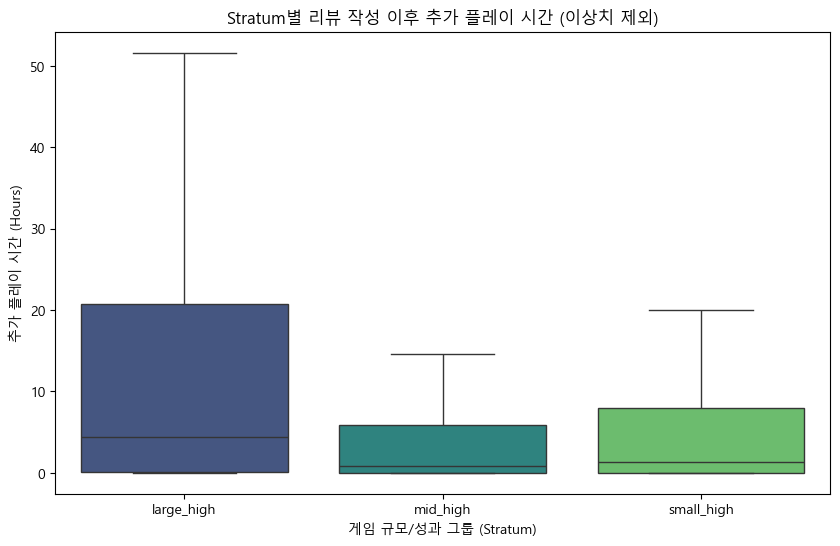

,count,mean,std,min,25%,50%,75%,max
stratum,,,,,,,,
large_high,5530.0,41.76,159.11,0.0,0.05,4.43,20.80,3080.97
mid_high,4390.0,7.94,23.75,0.0,0.00,0.78,5.88,388.27
small_high,3184.0,19.60,81.56,0.0,0.00,1.27,8.00,1551.93


In [7]:
# Stratum별 추가 플레이 시간 시각화 (이상치 제외하고 분포 집중 확인)
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x='stratum', y='playtime_after_review_hrs', 
            showfliers=False, palette='viridis')

plt.title('Stratum별 리뷰 작성 이후 추가 플레이 시간 (이상치 제외)')
plt.ylabel('추가 플레이 시간 (Hours)')
plt.xlabel('게임 규모/성과 그룹 (Stratum)')
plt.show()

# 기초 통계량 확인
display(merged_df.groupby('stratum')['playtime_after_review_hrs'].describe().round(2))

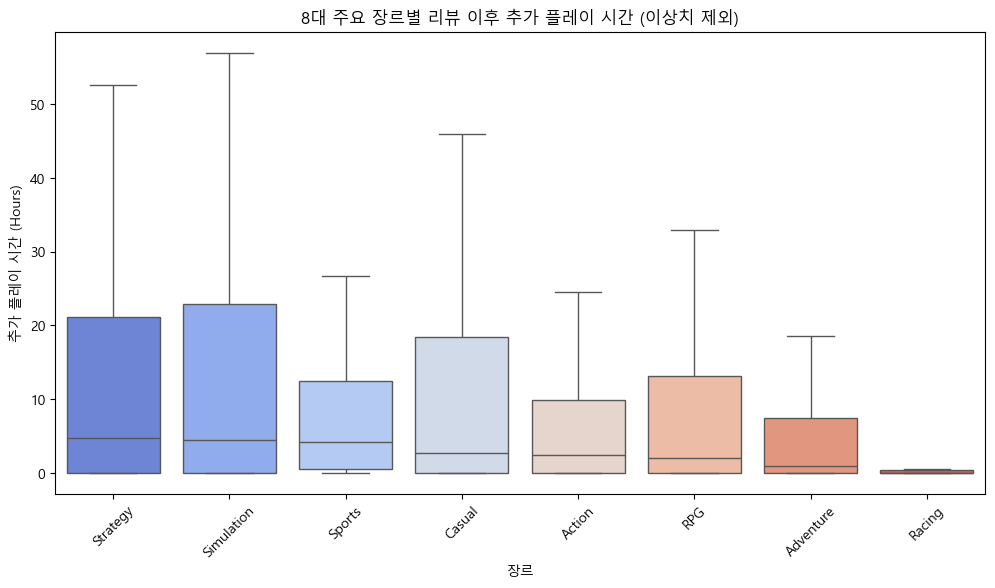

,50%,mean,count
genres_list,,,
Strategy,4.66,39.95,4032.0
Simulation,4.40,33.05,4924.0
Sports,4.12,15.29,188.0
Casual,2.70,37.02,5028.0
Action,2.47,20.43,5004.0
RPG,1.95,24.87,3682.0
Adventure,0.90,16.19,6330.0
Racing,0.00,0.47,22.0


In [8]:
# 장르별 중앙값 순으로 정렬하여 시각화
genre_order = filtered_df.groupby('genres_list')['playtime_after_review_hrs'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_df, x='genres_list', y='playtime_after_review_hrs', 
            order=genre_order, showfliers=False, palette='coolwarm')

plt.title('8대 주요 장르별 리뷰 이후 추가 플레이 시간 (이상치 제외)')
plt.ylabel('추가 플레이 시간 (Hours)')
plt.xlabel('장르')
plt.xticks(rotation=45)
plt.show()

# 장르별 통계 요약
genre_stats = filtered_df.groupby('genres_list')['playtime_after_review_hrs'].describe()[['50%', 'mean', 'count']].round(2)
display(genre_stats.sort_values(by='50%', ascending=False))

In [ ]:
# 이전 플레이타임과 긍부정 반응의 관계 분석의 추가분
# 타겟 장르 8개 전체의 플레이시간 구간 별 긍부정 비율
# 1. 긍정/부정 데이터 라벨링 및 사분위수 구간화
filtered_df['sentiment'] = filtered_df['voted_up'].str.lower().map({'true': 'Positive', 'false': 'Negative'})
filtered_df['playtime_q'] = filtered_df.groupby('genres_list')['author_playtime_at_review'].transform(
    lambda x: pd.qcut(x, q=4, labels=['Q1(라이트)', 'Q2', 'Q3', 'Q4(헤비)'])
)

# 2. 시각화를 위한 데이터 그룹화 (장르, 숙련도구간, 감성별로 개수 집계)
df_counts = filtered_df.groupby(['genres_list', 'playtime_q', 'sentiment']).size().reset_index(name='count')

# 3. px.bar()를 이용한 시각화
fig = px.bar(df_counts, 
            x="playtime_q", 
            y="count", 
            color="sentiment",
            facet_col="genres_list",   # 장르별로 차트 분리
            facet_col_wrap=4,          # 한 줄에 4개씩 배치
            barmode="stack",           # 누적 바 차트 형태
            color_discrete_map={'Positive': '#636EFA', 'Negative': '#EF553B'},
            title="8대 장르별 유저 숙련도 구간에 따른 긍정/부정 비율 (Stacked Bar)",
            labels={'playtime_q': '숙련도 구간', 'count': '리뷰 수'})

# 4. 레이아웃 조정 (Y축 단위 표시 및 서브플롯 제목 정돈)
fig.update_layout(
    yaxis_title="비율 (%)",
    template="plotly_white",
    margin=dict(t=80, b=50, l=50, r=50)
)

# 서브플롯 제목(장르 이름)에서 "genres_list=" 문구 제거
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()